In [9]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import copy
class StockDataset(Dataset):
    def __init__(self, data, lookback):
        self.data = torch.FloatTensor(data)
        self.lookback = lookback
        
    def __len__(self):
        return len(self.data) - self.lookback
        
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.lookback]
        y = self.data[idx + self.lookback]
        return x, y

class LSTM_GBM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTM_GBM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        
        # Predict mu (drift) and sigma (volatility)
        self.mu_head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        self.sigma_head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Softplus()  # Ensure positive volatility
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        
        mu = self.mu_head(last_hidden)
        sigma = self.sigma_head(last_hidden)
        
        return mu, sigma
    
    def save_model(self, filepath):
        """Save model and optimizer state"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_loss': self.best_loss
        }, filepath)

    def load_model(self, filepath):
        """Load model and optimizer state"""
        
        checkpoint = torch.load(filepath)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.best_loss = checkpoint['best_loss']

    def generate_gbm_price(self, S0, mu, sigma, dt=1, steps=1):
        """Generate GBM price path using predicted parameters"""
        device = mu.device
        batch_size = mu.shape[0]
        
        # Generate Brownian motion increments
        dW = torch.randn(batch_size, steps).to(device) * torch.sqrt(torch.tensor(dt).to(device))
        
        # Calculate price path
        drift = (mu - 0.5 * sigma**2) * dt
        diffusion = sigma * dW
        
        # Cumulative sum for path
        returns = drift + diffusion
        price = S0 * torch.exp(returns)
        
        return price

class HybridTrainer:
    def __init__(self, model, learning_rate=0.001):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        self.criterion = nn.MSELoss()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.best_model = None
        self.best_loss = float('inf')

    def train_step(self, x_batch, y_batch, S0_batch):
        self.model.train()
        self.optimizer.zero_grad()
        
        # Forward pass
        mu_pred, sigma_pred = self.model(x_batch)
        
        # Generate price using GBM
        price_pred = self.model.generate_gbm_price(S0_batch, mu_pred, sigma_pred)
        
        # Calculate loss
        loss = self.criterion(price_pred, y_batch)
        
        # Backward pass
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def train(self, train_loader, val_loader, num_epochs):
        train_loss_history = []
        val_loss_history = []
        
        for epoch in range(num_epochs):
            # Training
            self.model.train()
            train_epoch_loss = 0
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                S0_batch = x_batch[:, -1, 0].reshape(-1, 1)
                
                loss = self.train_step(x_batch, y_batch, S0_batch)
                train_epoch_loss += loss
            
            avg_train_loss = train_epoch_loss / len(train_loader)
            train_loss_history.append(avg_train_loss)
            
            # Validation
            self.model.eval()
            val_epoch_loss = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = x_batch.to(self.device)
                    y_batch = y_batch.to(self.device)
                    S0_batch = x_batch[:, -1, 0].reshape(-1, 1)
                    
                    mu_pred, sigma_pred = self.model(x_batch)
                    price_pred = self.model.generate_gbm_price(S0_batch, mu_pred, sigma_pred)
                    val_loss = self.criterion(price_pred, y_batch)
                    val_epoch_loss += val_loss.item()
            
            avg_val_loss = val_epoch_loss / len(val_loader)
            val_loss_history.append(avg_val_loss)
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            
            # Save best model
            if avg_val_loss < self.best_loss:
                self.best_loss = avg_val_loss
                self.best_model = copy.deepcopy(self.model.state_dict())
        
        # Load best model
        self.model.load_state_dict(self.best_model)
        return train_loss_history, val_loss_history

    def predict(self, test_loader):
        self.model.eval()
        predictions = []
        actuals = []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                S0_batch = x_batch[:, -1, 0].reshape(-1, 1)
                
                mu_pred, sigma_pred = self.model(x_batch)
                price_pred = self.model.generate_gbm_price(S0_batch, mu_pred, sigma_pred)
                
                predictions.extend(price_pred.cpu().numpy())
                actuals.extend(y_batch.cpu().numpy())
        
        return np.array(predictions), np.array(actuals)

    def predict(self, test_loader):
        self.model.eval()
        predictions = []
        actuals = []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                S0_batch = x_batch[:, -1, 0].reshape(-1, 1)
                
                mu_pred, sigma_pred = self.model(x_batch)
                price_pred = self.model.generate_gbm_price(S0_batch, mu_pred, sigma_pred)
                
                predictions.extend(price_pred.cpu().numpy())
                actuals.extend(y_batch.cpu().numpy())
        
        return np.array(predictions), np.array(actuals)

    def plot_results(self, train_loss_history, val_loss_history, predictions, actuals, scaler):
        import matplotlib.pyplot as plt
        
        # Plot loss curves
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(train_loss_history, label='Training Loss')
        plt.plot(val_loss_history, label='Validation Loss')
        plt.title('Loss Curves')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # Plot predictions vs actuals
        plt.subplot(1, 2, 2)
        plt.plot(scaler.inverse_transform(actuals), "+-", label='Actual')
        plt.plot(scaler.inverse_transform(predictions), "x--", label='Predicted')
        plt.title('Stock Price Prediction')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_prices(self, predictions, actuals, scaler):
        import matplotlib.pyplot as plt
        
        # Plot loss curves
        plt.figure(figsize=(15, 5))
        
        # Plot predictions vs actuals
        # plt.subplot(1, 2, 2)
        plt.plot(scaler.inverse_transform(actuals),"+-", label='Actual')
        plt.plot(scaler.inverse_transform(predictions),"x--", label='Predicted')
        plt.title('Stock Price Prediction')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

def prepare_data(data, lookback=20, train_split=0.7, val_split=0.15, batch_size=32,test_only=False):
    features = ['Close']
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data[features])
    
    dataset = StockDataset(scaled_data, lookback)
    
    # Split train/val/test
    total_size = len(dataset)
    if test_only:
        test_dataset = torch.utils.data.Subset(dataset, range(total_size))
        test_loader = DataLoader(test_dataset, shuffle=False)
        return test_loader
    train_size = int(total_size * train_split)
    val_size = int(total_size * val_split)
    test_size = total_size - train_size - val_size
    
    train_dataset = torch.utils.data.Subset(dataset, range(train_size))
    val_dataset = torch.utils.data.Subset(dataset, range(train_size, train_size + val_size))
    test_dataset = torch.utils.data.Subset(dataset, range(train_size + val_size, total_size))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, scaler

# Example usage:
"""
# Load and prepare data
data = pd.read_csv('stock_data.csv')
train_loader, test_loader, scaler = prepare_data(data)

# Initialize model
model = LSTM_GBM(
    input_size=1,  # Number of features
    hidden_size=64,
    num_layers=2,
    dropout=0.2
)

# Train model
trainer = HybridTrainer(model)
trainer.train(train_loader, num_epochs=100)
"""

"\n# Load and prepare data\ndata = pd.read_csv('stock_data.csv')\ntrain_loader, test_loader, scaler = prepare_data(data)\n\n# Initialize model\nmodel = LSTM_GBM(\n    input_size=1,  # Number of features\n    hidden_size=64,\n    num_layers=2,\n    dropout=0.2\n)\n\n# Train model\ntrainer = HybridTrainer(model)\ntrainer.train(train_loader, num_epochs=100)\n"

[*********************100%***********************]  1 of 1 completed


Epoch [10/100], Train Loss: 0.2142, Val Loss: 0.1082
Epoch [20/100], Train Loss: 0.0186, Val Loss: 0.0083
Epoch [30/100], Train Loss: 0.0059, Val Loss: 0.0047
Epoch [40/100], Train Loss: 0.0043, Val Loss: 0.0043
Epoch [50/100], Train Loss: 0.0037, Val Loss: 0.0039
Epoch [60/100], Train Loss: 0.0032, Val Loss: 0.0036
Epoch [70/100], Train Loss: 0.0028, Val Loss: 0.0039
Epoch [80/100], Train Loss: 0.0031, Val Loss: 0.0035
Epoch [90/100], Train Loss: 0.0029, Val Loss: 0.0037
Epoch [100/100], Train Loss: 0.0029, Val Loss: 0.0035


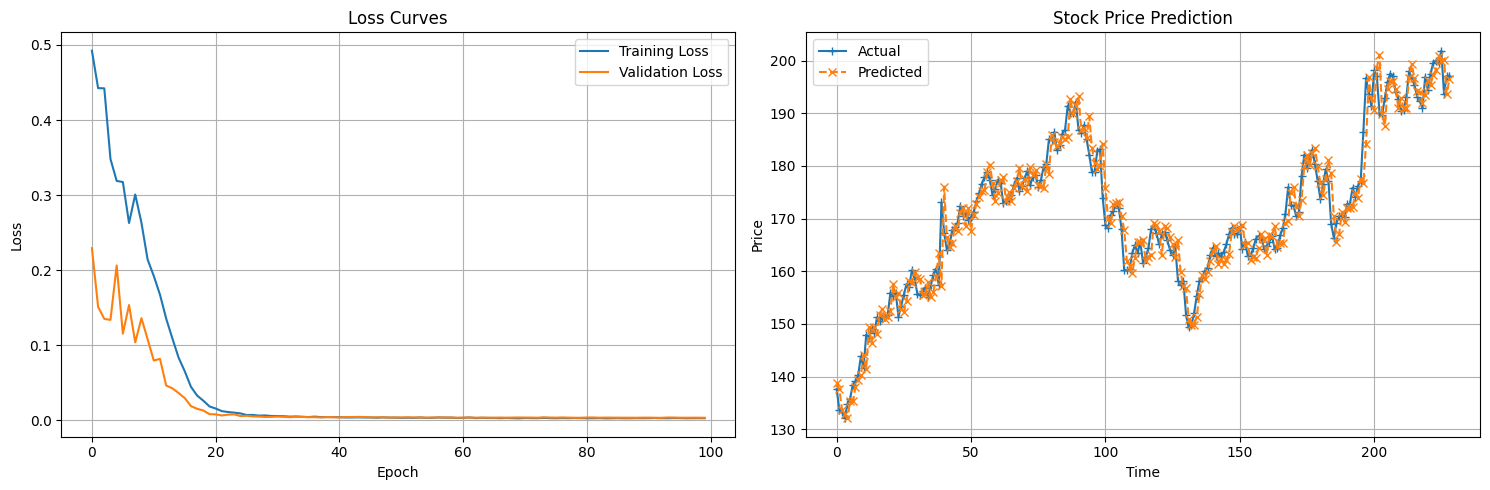

In [10]:
# """
# Load your data
import copy 
import yfinance as yf
rawdata = yf.download("GOOG", start="2019-01-01", end="2025-01-30")
df = rawdata.copy()
dates = list(df.index)
close_prices = df["Close"].values  # numpy array
volume = df["Volume"].values  # numpy array
open_prices = df["Open"].values  # numpy array
close_prices = close_prices.reshape(-1)
volume = volume.reshape(-1)
open_prices = open_prices.reshape(-1)
data = pd.DataFrame({
    'Date':dates,
    'Close':close_prices,
})
data = data.sort_values('Date')
train_loader, val_loader, test_loader, scaler = prepare_data(data,lookback=10,batch_size=256)

# Initialize and train model
model = LSTM_GBM(input_size=1, hidden_size=16, num_layers=4,dropout=0.3)
trainer = HybridTrainer(model,learning_rate=0.001)
train_loss_history, val_loss_history = trainer.train(train_loader, val_loader, num_epochs=100)

# Get predictions
predictions, actuals = trainer.predict(test_loader)

# Plot results
trainer.plot_results(train_loss_history, val_loss_history, predictions, actuals, scaler)

[*********************100%***********************]  1 of 1 completed


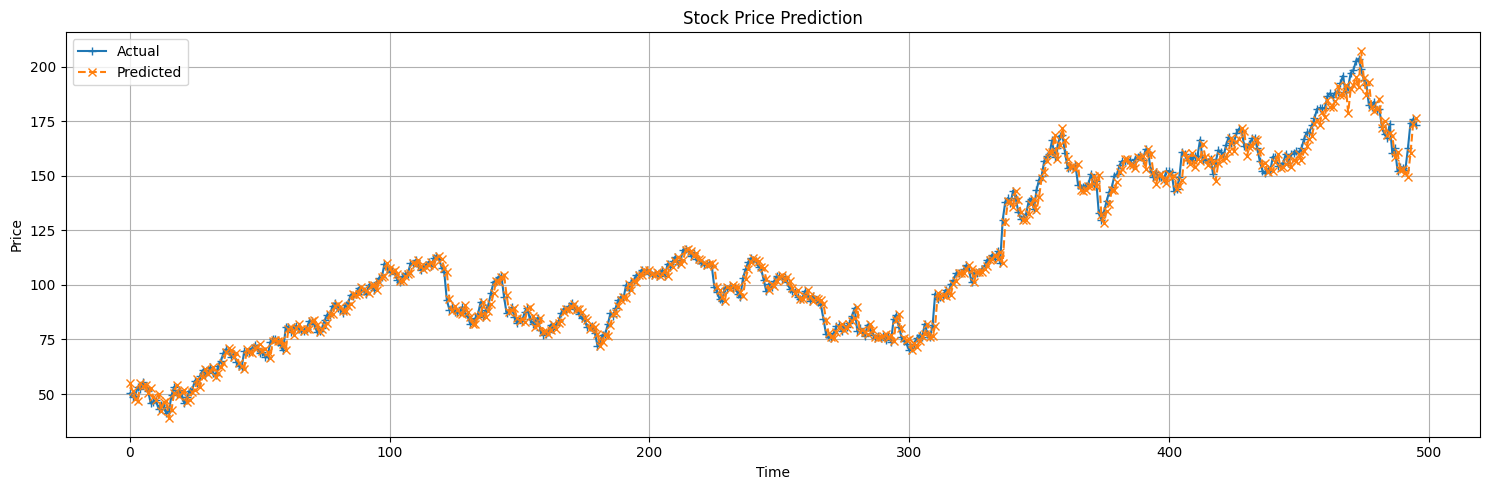

In [11]:
# """
# Load your data
import copy 
import yfinance as yf
rawdata = yf.download("AAPL", start="2023-02-01", end="2025-01-31")
df = rawdata.copy()
dates = list(df.index)
close_prices = df["Close"].values  # numpy array
volume = df["Volume"].values  # numpy array
open_prices = df["Open"].values  # numpy array
close_prices = close_prices.reshape(-1)
volume = volume.reshape(-1)
open_prices = open_prices.reshape(-1)
data = pd.DataFrame({
    'Date':dates,
    'Close':close_prices,
})
data = data.sort_values('Date')
test_loader = prepare_data(data,val_split=0,train_split=0,lookback=5,batch_size=256,test_only=True)
predictions, actuals = trainer.predict(test_loader)
# """
trainer.plot_prices(predictions, actuals, scaler)
